In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNetCV, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import pearsonr

In [2]:
data_file = Path("../data/processed/H13_promoters_651motifs_with_TPM.csv")

df = pd.read_csv(data_file)
df = df.dropna(subset=["log2_TPM_plus1"]).copy()

print(df.shape)
display(df.head())

(20007, 654)


,promoter_id,AHCTF1.H13CORE.0.B.B,AHR.H13CORE.0.P.B,ALX1.H13CORE.0.SM.B,ANDR.H13CORE.1.S.C,ANDR.H13CORE.2.P.B,AP2A.H13CORE.0.PSM.A,ARNT.H13CORE.0.P.B,ARNT2.H13CORE.0.P.B,ATF1.H13CORE.1.P.B,...,ZSC29.H13CORE.1.M.C,ZSC31.H13CORE.0.P.C,ZSCA1.H13CORE.0.SM.B,ZSCAN12.H13CORE.0.P.B,ZSCAN2.H13CORE.0.PG.A,ZSCAN25.H13CORE.0.PSG.A,ZXDA.H13CORE.0.PSI.A,ZXDC.H13CORE.0.PI.A,gene_symbol,log2_TPM_plus1
0,gene-OR4F16|OR4F16|chr1:107876-117877|-,302.332236,17.941461,34.013831,164.797344,335.398194,3.790701,48.721730,144.299281,18.516320,...,12.155462,35.184567,2.758547,138.829016,0.365287,7.726213,36.682951,15.609821,OR4F16,0.150560
1,gene-SAMD11|SAMD11|chr1:348565-358566|+,19.340017,106.962620,0.704667,67.601283,58.273912,126.511248,105.848932,225.198969,111.177175,...,2.670962,179.830138,9.959176,266.290223,0.000000,95.240338,400.288574,121.867755,SAMD11,5.361768
2,gene-NOC2L|NOC2L|chr1:383040-393041|-,43.043277,110.551691,0.630066,64.879750,106.249774,163.746683,107.512710,195.744209,120.124106,...,2.299665,180.647134,3.405136,276.570075,0.246302,67.752125,311.213273,105.019855,NOC2L,7.795195
3,gene-KLHL17|KLHL17|chr1:384373-394374|+,24.091429,99.126770,1.826247,59.478485,72.509248,194.859057,106.007893,190.749799,121.381597,...,2.205529,204.674574,3.148192,278.045765,0.380648,68.033367,350.141791,129.096476,KLHL17,4.693766
4,gene-PLEKHN1|PLEKHN1|chr1:390192-400193|+,28.317637,139.136414,5.733277,80.299276,137.485214,166.712558,175.525151,308.016942,80.768011,...,12.315560,193.470044,28.377810,255.382943,0.246302,89.286750,318.594021,135.428670,PLEKHN1,0.000000


In [3]:
target_col = "log2_TPM_plus1"

exclude_cols = [
    "promoter_id",
    "gene_symbol",
    target_col
]

feature_cols = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols]
y = df[target_col]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.10,
    random_state=42
)

print(X_train.shape, X_test.shape)

(18006, 651) (2001, 651)


In [5]:
elastic_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
        alphas=np.logspace(-3, 2, 50),
        cv=5,
        max_iter=10000,
        n_jobs=-1,
        random_state=42
    ))
])

elastic_cv.fit(X_train, y_train)

best_elastic = elastic_cv.named_steps["model"]

print("Best alpha:", best_elastic.alpha_)
print("Best l1_ratio:", best_elastic.l1_ratio_)
print("Non-zero coefficients:", np.sum(best_elastic.coef_ != 0))

c:\Users\1\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 11.20185548113659, tolerance: 9.56320305215297
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\1\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 20.473212223405426, tolerance: 9.504297965176608
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\1\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 27.34300328117388, tolerance: 9.384225395497412
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\1\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning

Best alpha: 0.006551285568595509
Best l1_ratio: 0.9
Non-zero coefficients: 352


c:\Users\1\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.826e+01, tolerance: 1.192e+01
  model = cd_fast.enet_coordinate_descent(


In [6]:
y_pred = elastic_cv.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
pearson_r, pearson_p = pearsonr(y_test, y_pred)

print("R²:", r2)
print("RMSE:", rmse)
print("Pearson r:", pearson_r)
print("Pearson p:", pearson_p)

R²: 0.3848434011182569
RMSE: 1.9995335470077336
Pearson r: 0.6211662303727559
Pearson p: 6.9186719808602205e-214


In [8]:
coef_df = pd.DataFrame({
    "motif": feature_cols,
    "coefficient": best_elastic.coef_
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

print("Non-zero coefficients:", (coef_df["coefficient"] != 0).sum())
display(coef_df.head(30))

Non-zero coefficients: 352


,motif,coefficient,abs_coefficient
311,ZFX.H13CORE.0.P.B,0.336073,0.336073
553,ZNF292.H13CORE.0.PSG.A,-0.316095,0.316095
220,SP140.H13CORE.0.PSGIB.A,0.291954,0.291954
35,DNTTIP1.H13CORE.0.PSG.A,-0.256578,0.256578
72,GTF2IRD2.H13CORE.0.PS.A,0.234683,0.234683
140,NFIC.H13CORE.1.PSM.A,-0.229332,0.229332
57,GABPA.H13CORE.0.PSM.A,0.204216,0.204216
159,NRF1.H13CORE.0.PS.A,0.194705,0.194705
560,ZNF35.H13CORE.1.P.C,0.177159,0.177159
257,TYY1.H13CORE.0.PSM.A,0.173565,0.173565


In [9]:
coef_df.to_csv("../results/H13_ElasticNet_coefficients.csv", index=False)

print("Saved", len(coef_df), "motif coefficients.")

Saved 651 motif coefficients.


In [10]:
high_cut = df["log2_TPM_plus1"].quantile(0.90)
low_cut = df["log2_TPM_plus1"].quantile(0.10)

high_expr = df[df["log2_TPM_plus1"] >= high_cut]
low_expr = df[df["log2_TPM_plus1"] <= low_cut]

print("High TPM promoters:", len(high_expr))
print("Low TPM promoters:", len(low_expr))
print("High cutoff:", high_cut)
print("Low cutoff:", low_cut)

high_means = high_expr[feature_cols].mean()
low_means = low_expr[feature_cols].mean()

high_vars = high_expr[feature_cols].var(ddof=1)
low_vars = low_expr[feature_cols].var(ddof=1)

pooled_std = np.sqrt((high_vars + low_vars) / 2) + 1e-8
cohens_d = (high_means - low_means) / pooled_std

cohens_d_df = pd.DataFrame({
    "motif": feature_cols,
    "cohens_d": cohens_d.values
})

cohens_d_df["abs_cohens_d"] = cohens_d_df["cohens_d"].abs()
cohens_d_df = cohens_d_df.sort_values("abs_cohens_d", ascending=False)

display(cohens_d_df.head(30))

High TPM promoters: 2001
Low TPM promoters: 4148
High cutoff: 6.185073556129985
Low cutoff: 0.0


,motif,cohens_d,abs_cohens_d
114,MBD1.H13CORE.0.PSIB.A,1.521003,1.521003
220,SP140.H13CORE.0.PSGIB.A,1.407549,1.407549
127,MYCN.H13CORE.1.M.C,1.258861,1.258861
219,SP100.H13CORE.0.PSGI.A,1.216936,1.216936
406,ZN441.H13CORE.0.P.C,1.175405,1.175405
130,MYPOP.H13CORE.0.PSGB.A,1.167814,1.167814
412,ZN454.H13CORE.1.SM.B,1.154323,1.154323
20,CGGBP1.H13CORE.0.PSGIB.A,1.148348,1.148348
38,E2F1.H13CORE.0.P.B,1.110284,1.110284
133,NACC2.H13CORE.0.PSGIB.A,-1.096894,1.096894


In [11]:
motif_results = cohens_d_df.merge(
    coef_df,
    on="motif",
    how="left"
)

motif_results = motif_results.sort_values("abs_cohens_d", ascending=False)

display(motif_results.head(30))

,motif,cohens_d,abs_cohens_d,coefficient,abs_coefficient
0,MBD1.H13CORE.0.PSIB.A,1.521003,1.521003,0.000000,0.000000
1,SP140.H13CORE.0.PSGIB.A,1.407549,1.407549,0.291954,0.291954
2,MYCN.H13CORE.1.M.C,1.258861,1.258861,0.002533,0.002533
3,SP100.H13CORE.0.PSGI.A,1.216936,1.216936,0.021748,0.021748
4,ZN441.H13CORE.0.P.C,1.175405,1.175405,0.011871,0.011871
5,MYPOP.H13CORE.0.PSGB.A,1.167814,1.167814,-0.000000,0.000000
6,ZN454.H13CORE.1.SM.B,1.154323,1.154323,-0.040401,0.040401
7,CGGBP1.H13CORE.0.PSGIB.A,1.148348,1.148348,0.000000,0.000000
8,E2F1.H13CORE.0.P.B,1.110284,1.110284,0.000000,0.000000
9,NACC2.H13CORE.0.PSGIB.A,-1.096894,1.096894,-0.117260,0.117260


In [12]:
coef_df.to_csv("../results/H13_ElasticNet_coefficients.csv", index=False)
cohens_d_df.to_csv("../results/H13_cohens_d_enrichment.csv", index=False)
motif_results.to_csv("../results/H13_motif_enrichment_with_ElasticNet_weights.csv", index=False)

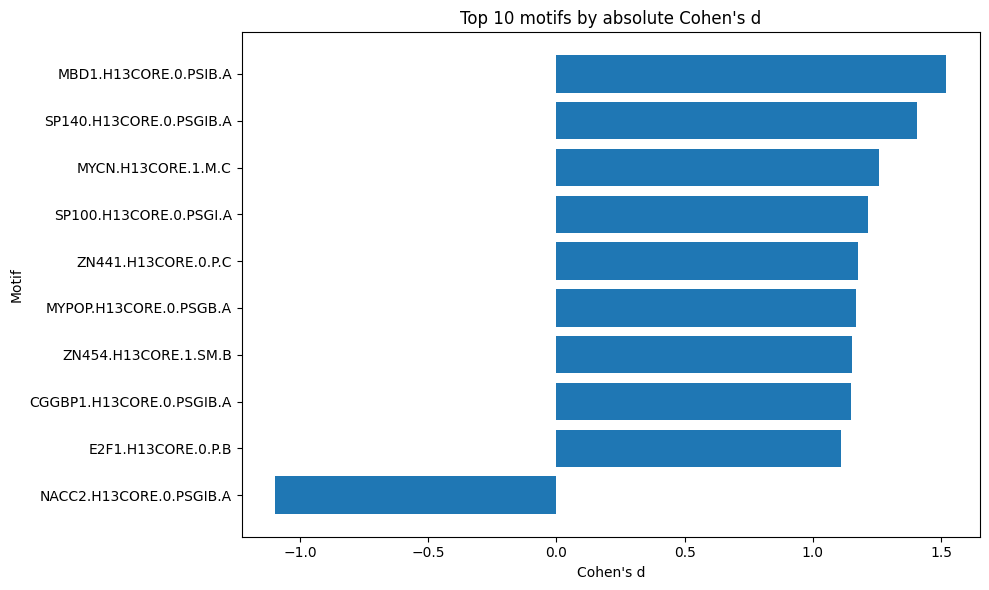

In [13]:
top10 = cohens_d_df.nlargest(10, "abs_cohens_d")

plt.figure(figsize=(10, 6))

plt.barh(
    top10["motif"],
    top10["cohens_d"]
)

plt.xlabel("Cohen's d")
plt.ylabel("Motif")
plt.title("Top 10 motifs by absolute Cohen's d")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

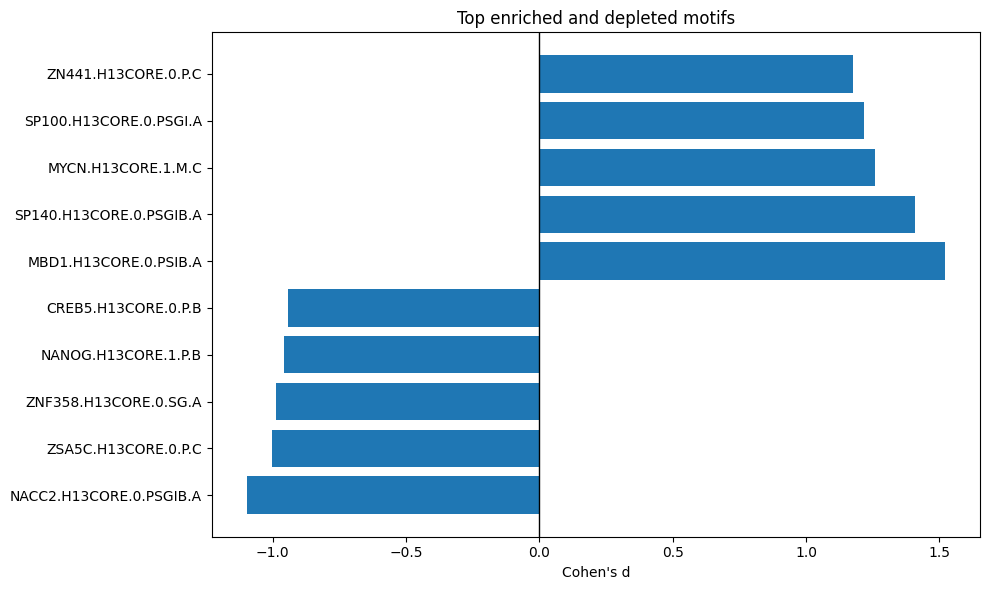

In [27]:
top_positive = cohens_d_df.nlargest(5, "cohens_d")
top_negative = cohens_d_df.nsmallest(5, "cohens_d")

plot_df = pd.concat([top_negative, top_positive])

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["motif"],
    plot_df["cohens_d"]
)

plt.axvline(0, color="black", linewidth=1)

plt.xlabel("Cohen's d")
plt.title("Top enriched and depleted motifs")

plt.tight_layout()
plt.show()

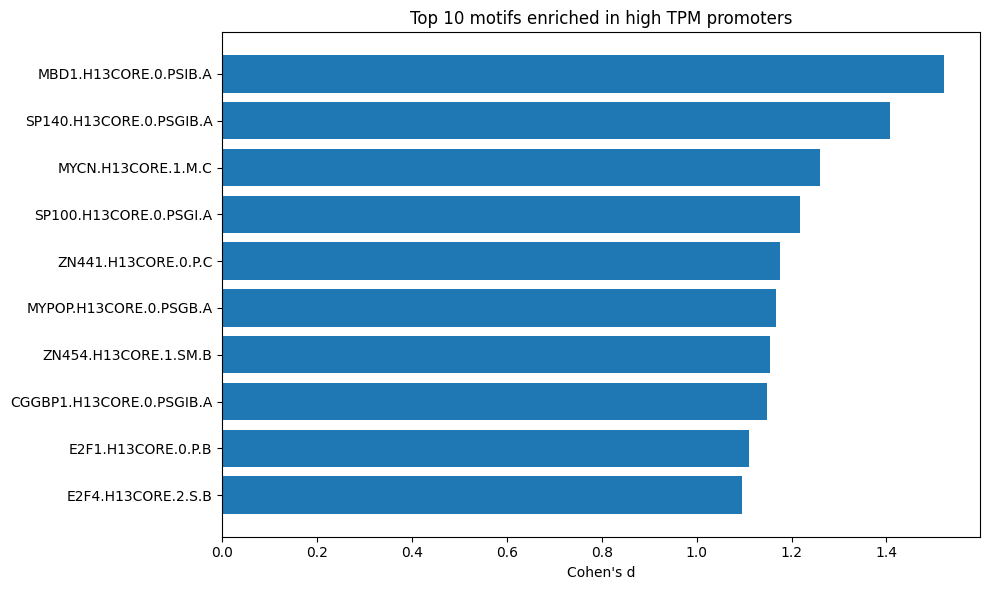

In [28]:
top_high = cohens_d_df.nlargest(10, "cohens_d")

plt.figure(figsize=(10, 6))
plt.barh(top_high["motif"], top_high["cohens_d"])

plt.xlabel("Cohen's d")
plt.title("Top 10 motifs enriched in high TPM promoters")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

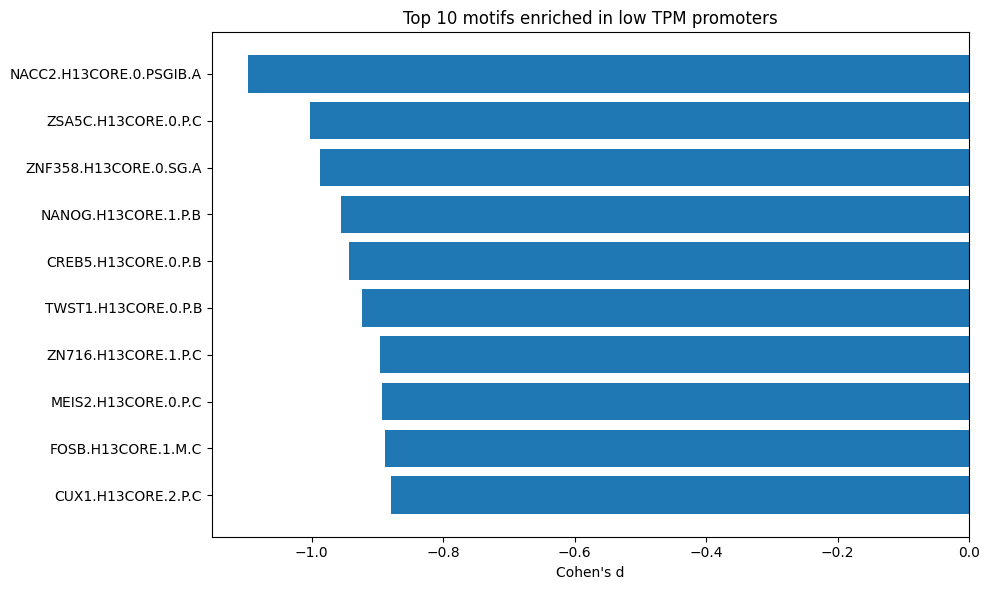

In [16]:
top_low = cohens_d_df.nsmallest(10, "cohens_d")

plt.figure(figsize=(10, 6))
plt.barh(top_low["motif"], top_low["cohens_d"])

plt.xlabel("Cohen's d")
plt.title("Top 10 motifs enriched in low TPM promoters")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [17]:
old_file = r"C:\disk_D\MASTER\promoter_motif_expression\data\processed\motif_matrices\promoter_motif_M_woTFTPM0.csv"

old_df = pd.read_csv(old_file)

tpm_col = old_df.columns[-1]

print("TPM column:", tpm_col)
print("Rows:", len(old_df))
print("Minimum TPM:", old_df[tpm_col].min())
print("TPM == 0:", (old_df[tpm_col] == 0).sum())

TPM column: log2_TPM_plus1
Rows: 20007
Minimum TPM: 0.0
TPM == 0: 4148


## NOW WE EXCLUDE THE TPM = 0 BEFORE RUNNING THE ENRICHMENT

In [18]:
df_expr = df[df["log2_TPM_plus1"] > 0].copy()

print("Original promoters:", len(df))
print("Expressed promoters:", len(df_expr))

Original promoters: 20007
Expressed promoters: 15859


In [19]:
high_cut = df_expr["log2_TPM_plus1"].quantile(0.90)
low_cut = df_expr["log2_TPM_plus1"].quantile(0.10)

high_expr = df_expr[df_expr["log2_TPM_plus1"] >= high_cut]
low_expr = df_expr[df_expr["log2_TPM_plus1"] <= low_cut]

print("High TPM promoters:", len(high_expr))
print("Low TPM promoters:", len(low_expr))

High TPM promoters: 1586
Low TPM promoters: 1611


In [20]:
n = int(len(df_expr) * 0.10)

sorted_df = df_expr.sort_values("log2_TPM_plus1")

low_expr = sorted_df.head(n)
high_expr = sorted_df.tail(n)

print("High TPM promoters:", len(high_expr))
print("Low TPM promoters:", len(low_expr))

High TPM promoters: 1585
Low TPM promoters: 1585


In [21]:
high_means = high_expr[feature_cols].mean()
low_means = low_expr[feature_cols].mean()

high_vars = high_expr[feature_cols].var(ddof=1)
low_vars = low_expr[feature_cols].var(ddof=1)

pooled_std = np.sqrt((high_vars + low_vars) / 2) + 1e-8

cohens_d_expr = (high_means - low_means) / pooled_std

cohens_d_expr_df = pd.DataFrame({
    "motif": feature_cols,
    "cohens_d": cohens_d_expr.values
})

cohens_d_expr_df["abs_cohens_d"] = cohens_d_expr_df["cohens_d"].abs()
cohens_d_expr_df = cohens_d_expr_df.sort_values(
    "abs_cohens_d",
    ascending=False
)

display(cohens_d_expr_df.head(15))

,motif,cohens_d,abs_cohens_d
220,SP140.H13CORE.0.PSGIB.A,1.244204,1.244204
114,MBD1.H13CORE.0.PSIB.A,1.206745,1.206745
219,SP100.H13CORE.0.PSGI.A,1.074478,1.074478
127,MYCN.H13CORE.1.M.C,0.963185,0.963185
39,E2F4.H13CORE.2.S.B,0.940286,0.940286
232,TAL1.H13CORE.1.P.B,-0.926512,0.926512
8,ATF1.H13CORE.1.P.B,0.900938,0.900938
67,GMEB1.H13CORE.2.SM.B,0.881196,0.881196
281,ZBT37.H13CORE.0.M.C,0.874123,0.874123
130,MYPOP.H13CORE.0.PSGB.A,0.871199,0.871199


In [22]:
top15_high = cohens_d_expr_df.nlargest(15, "cohens_d")

display(top15_high[["motif", "cohens_d"]])

,motif,cohens_d
220,SP140.H13CORE.0.PSGIB.A,1.244204
114,MBD1.H13CORE.0.PSIB.A,1.206745
219,SP100.H13CORE.0.PSGI.A,1.074478
127,MYCN.H13CORE.1.M.C,0.963185
39,E2F4.H13CORE.2.S.B,0.940286
8,ATF1.H13CORE.1.P.B,0.900938
67,GMEB1.H13CORE.2.SM.B,0.881196
281,ZBT37.H13CORE.0.M.C,0.874123
130,MYPOP.H13CORE.0.PSGB.A,0.871199
102,KAISO.H13CORE.0.P.B,0.851848


In [23]:
top15_low = cohens_d_expr_df.nsmallest(15, "cohens_d")

display(top15_low[["motif", "cohens_d"]])

,motif,cohens_d
232,TAL1.H13CORE.1.P.B,-0.926512
283,ZBT44.H13CORE.0.P.C,-0.776222
256,TWST1.H13CORE.0.P.B,-0.761946
318,ZKSC8.H13CORE.1.P.B,-0.755289
133,NACC2.H13CORE.0.PSGIB.A,-0.752839
637,ZSA5C.H13CORE.0.P.C,-0.752731
561,ZNF358.H13CORE.0.SG.A,-0.751120
263,Z280A.H13CORE.0.P.B,-0.740492
495,ZN716.H13CORE.1.P.C,-0.697812
614,ZNF780B.H13CORE.0.PSGI.A,-0.671351


In [24]:
top15_high.to_csv(
    "../results/H13_top15_high_expression_motifs_TPMgt0.csv",
    index=False
)

top15_low.to_csv(
    "../results/H13_top15_low_expression_motifs_TPMgt0.csv",
    index=False
)

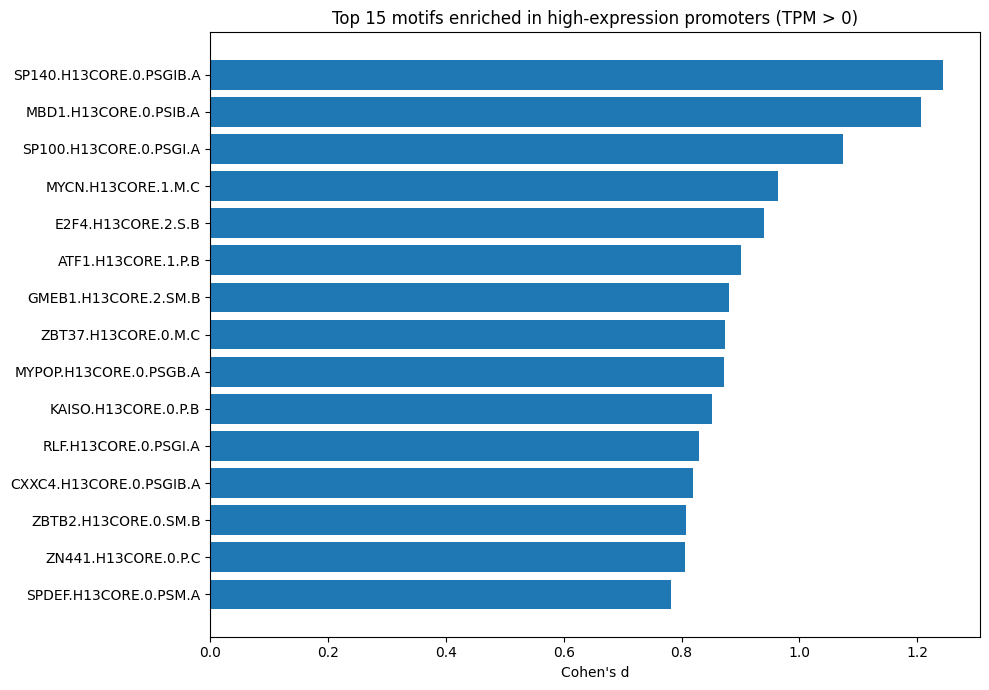

In [25]:
plt.figure(figsize=(10, 7))
plt.barh(top15_high["motif"], top15_high["cohens_d"])
plt.gca().invert_yaxis()
plt.xlabel("Cohen's d")
plt.title("Top 15 motifs enriched in high-expression promoters (TPM > 0)")
plt.tight_layout()
plt.show()

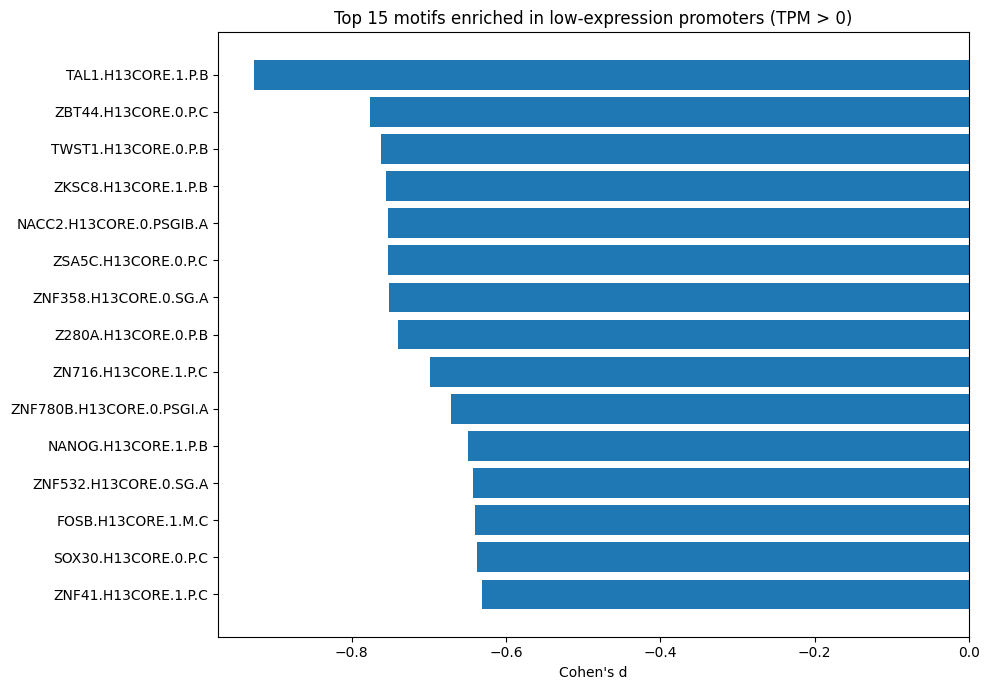

In [26]:
plt.figure(figsize=(10, 7))
plt.barh(top15_low["motif"], top15_low["cohens_d"])
plt.gca().invert_yaxis()
plt.xlabel("Cohen's d")
plt.title("Top 15 motifs enriched in low-expression promoters (TPM > 0)")
plt.tight_layout()
plt.show()